# 01 - Instance Segmentation: Data Preparation and Mask Generation

## Notebook Objective
This notebook prepares the dataset for the Instance Segmentation task using a Mask R-CNN architecture. 

While the previous data extraction script relied on bounding boxes to crop tissue patches, training a segmentation model requires exact pixel-level ground truth. This script parses the polygonal spatial coordinates from the provided `.xml` annotations and rasterizes them into binary masks. 

For every extracted tissue patch containing a glomerulus, a corresponding mask is generated of the exact same dimensions. In these masks, the background is represented by `0` and the glomerular tissue by `1` (or `255` for visualization purposes), providing the precise boundary data needed to train the parallel fully convolutional branch of the Mask R-CNN.

---
### Setup and First Glomerulus Mask Generation

In [2]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import openslide
from sklearn.model_selection import GroupKFold, train_test_split

Loading WSI...
Mask Array Shape: (1010, 1147) | Unique values: [  0 255]


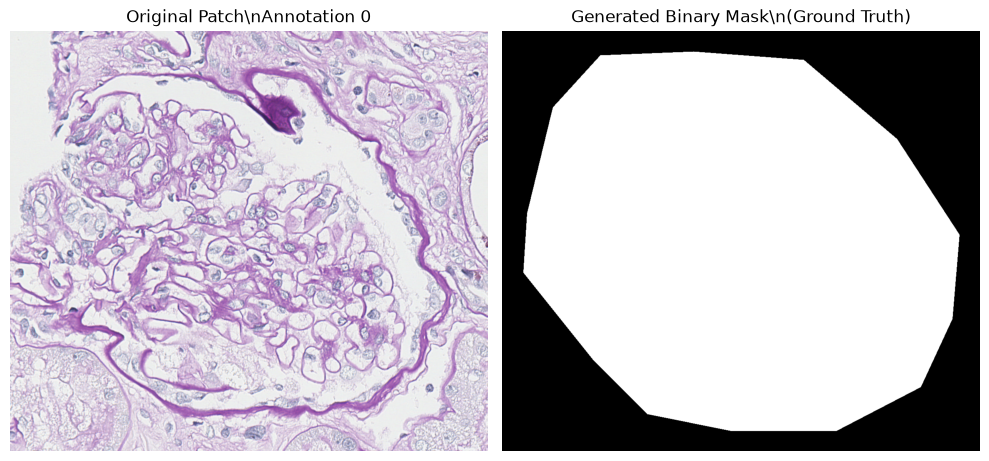

In [3]:

# Define file paths
wsi_path = "./glomeruli_grading/RECHERCHE-003.svs"   
xml_path = "./glomeruli_grading/RECHERCHE-003.xml"

# Load the WSI into memory
print("Loading WSI...")
slide = openslide.OpenSlide(wsi_path)

# Parse the XML file
tree = ET.parse(xml_path)
root = tree.getroot()

# Get the first annotation
first_annotation = root.find('.//Annotation')
annotation_name = first_annotation.get('Name')

# Extract X and Y coordinates for the polygon
x_coords = [float(coord.get('X')) for coord in first_annotation.findall('.//Coordinate')]
y_coords = [float(coord.get('Y')) for coord in first_annotation.findall('.//Coordinate')]

# Calculate the Bounding Box with a safety margin (same as previous notebook)
margin = 50
start_x = int(min(x_coords)) - margin
start_y = int(min(y_coords)) - margin
width = int(max(x_coords) - min(x_coords)) + (margin * 2)
height = int(max(y_coords) - min(y_coords)) + (margin * 2)

# 1. Extract the raw image patch
glomerulus_patch = slide.read_region((start_x, start_y), 0, (width, height)).convert("RGB")

# 2. Generate the Binary Mask
# Shift the global XML coordinates to be relative to the local patch's top-left corner
polygon_coords = [(x - start_x, y - start_y) for x, y in zip(x_coords, y_coords)]

# Initialize a completely black mask (0) using 'L' mode for 8-bit pixels
mask_image = Image.new('L', (width, height), 0)
draw = ImageDraw.Draw(mask_image)

# Draw the polygon. We use 255 (white) for clear visualization. 
# During model training, this array can easily be converted to 0 and 1.
draw.polygon(polygon_coords, outline=255, fill=255)

# Convert to a NumPy array for structural verification
mask_array = np.array(mask_image)
print(f"Mask Array Shape: {mask_array.shape} | Unique values: {np.unique(mask_array)}")

# 3. Visualize the Image-Mask Pair
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(glomerulus_patch)
axes[0].set_title(f"Original Patch\\n{annotation_name}")
axes[0].axis("off")

axes[1].imshow(mask_array, cmap="gray")
axes[1].set_title("Generated Binary Mask\\n(Ground Truth)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Batch Extraction and Metadata Collection

Now we scale the single-image extraction to the entire dataset. This loop will:
1. Iterate through every WSI and its corresponding XML.
2. Extract the cropped `RGB` patch and draw the exact `1` and `0` binary mask.
3. Save the pairs into dedicated `images` and `masks` directories.
4. Generate a metadata CSV that records which WSI each patch came from.

In [5]:
# 1. Define input and output directories
dataset_dir = "./glomeruli_grading/"
save_dir_images = "./dataset_instance_seg/images"
save_dir_masks = "./dataset_instance_seg/masks"

# Create the directories if they don't exist
os.makedirs(save_dir_images, exist_ok=True)
os.makedirs(save_dir_masks, exist_ok=True)

# Find all SVS files currently available locally
svs_files = glob.glob(os.path.join(dataset_dir, "*.svs"))
print(f"Found {len(svs_files)} WSI files for processing.")

total_extracted = 0
metadata = [] 

# 2. Iterate through each WSI
for wsi_path in svs_files:
    file_name = os.path.basename(wsi_path)
    base_name = file_name.replace(".svs", "")
    xml_path = wsi_path.replace(".svs", ".xml")
    
    if not os.path.exists(xml_path):
        print(f"WARNING: XML not found for {file_name}. Skipping...")
        continue
        
    print(f"Processing: {file_name}")
    
    try:
        slide = openslide.OpenSlide(wsi_path)
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"  -> ERROR loading {file_name}: {e}")
        continue
        
    annotations = root.findall('.//Annotation')
    
    # 3. Iterate through every annotated glomerulus in the slide
    for idx, annotation in enumerate(annotations):
        coordinates = annotation.findall('.//Coordinate')
        
        # Skip invalid annotations
        if len(coordinates) < 3:
            continue
            
        x_coords = [float(coord.get('X')) for coord in coordinates]
        y_coords = [float(coord.get('Y')) for coord in coordinates]
        
        # Calculate bounding box
        margin = 50
        start_x = int(min(x_coords)) - margin
        start_y = int(min(y_coords)) - margin
        width = int(max(x_coords) - min(x_coords)) + (margin * 2)
        height = int(max(y_coords) - min(y_coords)) + (margin * 2)
        
        # Extract patch
        try:
            patch = slide.read_region((start_x, start_y), 0, (width, height)).convert("RGB")
        except Exception as e:
            print(f"  -> ERROR reading patch {idx}: {e}")
            continue
            
        # Shift coordinates for the mask
        polygon_coords = [(x - start_x, y - start_y) for x, y in zip(x_coords, y_coords)]
        
        # Create binary mask (0 for background, 1 for glomerulus)
        mask_image = Image.new('L', (width, height), 0)
        draw = ImageDraw.Draw(mask_image)
        draw.polygon(polygon_coords, outline=1, fill=1)
        
        # 4. Save Image and Mask with matching filenames
        save_name = f"{base_name}_glom_{idx}.png"
        patch.save(os.path.join(save_dir_images, save_name))
        mask_image.save(os.path.join(save_dir_masks, save_name))
        
        # Store metadata for train/val split
        metadata.append({
            "patch_name": save_name,
            "slide_id": base_name,
            "width": width,
            "height": height
        })
        
        total_extracted += 1
        
    slide.close()

print(f"\nPROCESS COMPLETE! Successfully extracted {total_extracted} image-mask pairs.")

# 5. Save metadata
df_metadata = pd.DataFrame(metadata)
df_metadata.to_csv("./dataset_instance_seg/patch_metadata.csv", index=False)

Found 9 WSI files for processing.
Processing: RECHERCHE-009.svs
Processing: RECHERCHE-004.svs
Processing: RECHERCHE-010.svs
Processing: RECHERCHE-011.svs
Processing: RECHERCHE-005.svs
Processing: RECHERCHE-015.svs
Processing: RECHERCHE-016.svs
Processing: RECHERCHE-003.svs
Processing: RECHERCHE-017.svs

PROCESS COMPLETE! Successfully extracted 677 image-mask pairs.


### WSI-Level Train/Validation Split (80/20)

Because neighboring patches from the same biopsy slide share identical staining profiles and tissue characteristics, random data splitting causes **data leakage**. The model would "memorize" the slide instead of learning the universal features of a glomerulus.

To prevent this, we extract the unique slide IDs and perform our 80/20 split on the slides themselves. We then map those assignments back to the individual patches.

In [6]:
# Load the generated metadata
df = pd.read_csv("./dataset_instance_seg/patch_metadata.csv")

# 1. Extract unique slide IDs
unique_slides = df['slide_id'].unique()
print(f"Total Unique WSIs: {len(unique_slides)}")

# 2. Split the slides 80/20
train_slides, val_slides = train_test_split(unique_slides, test_size=0.2, random_state=42)

# 3. Function to map the split assignment back to the patches
def assign_split(slide_id):
    if slide_id in train_slides:
        return 'train'
    else:
        return 'val'

# Apply the mapping
df['split'] = df['slide_id'].apply(assign_split)

print("\n--- Patch Distribution ---")
print(df['split'].value_counts())

print("\n--- Slide Isolation Verification ---")
print(f"Training Slides: {train_slides}")
print(f"Validation Slides: {val_slides}")

# Save the final train/val metadata
df.to_csv("./dataset_instance_seg/train_val_metadata.csv", index=False)
print("\nTrain/Validation metadata successfully saved.")

Total Unique WSIs: 9

--- Patch Distribution ---
split
train    535
val      142
Name: count, dtype: int64

--- Slide Isolation Verification ---
Training Slides: <StringArray>
['RECHERCHE-015', 'RECHERCHE-009', 'RECHERCHE-017', 'RECHERCHE-010',
 'RECHERCHE-005', 'RECHERCHE-011', 'RECHERCHE-016']
Length: 7, dtype: str
Validation Slides: <StringArray>
['RECHERCHE-003', 'RECHERCHE-004']
Length: 2, dtype: str

Train/Validation metadata successfully saved.


### PyTorch Custom Dataset (Data Loader)

To train a Mask R-CNN, PyTorch requires a custom `Dataset` class that retrieves the images and their corresponding targets. The target must be a dictionary containing:
*   `boxes`: The bounding box coordinates `[xMin, yMin, xMax, yMax]`.
*   `labels`: The class label (1 for glomerulus, 0 for background).
*   `masks`: The exact pixel-level binary mask.

This class reads the `train_val_metadata.csv` we generated, dynamically calculates the bounding boxes directly from the masks on the fly, and converts the images into PyTorch Tensors.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F

class GlomeruliDataset(Dataset):
    def __init__(self, metadata_df, images_dir, masks_dir):
        self.df = metadata_df.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve filenames from metadata
        img_name = self.df.iloc[idx]['patch_name']
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name)

        # Load image and mask
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path) # Grayscale ('L' mode)

        # Convert mask to numpy array
        mask_np = np.array(mask)
        
        # Object ids (background is 0, glomerulus is 1)
        obj_ids = np.unique(mask_np)[1:]

        # Split the color-encoded mask into a set of boolean masks
        masks = mask_np == obj_ids[:, None, None]
        num_objs = len(obj_ids)

        # Get bounding box coordinates for each mask
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # Convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # There is only one class (glomerulus = 1)
        labels = torch.ones((num_objs,), dtype=torch.int64) 
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Create the target dictionary expected by Mask R-CNN
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        # Convert PIL image to PyTorch Tensor [C, H, W] in range [0, 1]
        img_tensor = F.to_tensor(img)

        return img_tensor, target

# Initialize datasets based on our 80/20 slide-level split
df_full = pd.read_csv("./dataset_instance_seg/train_val_metadata.csv")
train_df = df_full[df_full['split'] == 'train']
val_df = df_full[df_full['split'] == 'val']

train_dataset = GlomeruliDataset(train_df, save_dir_images, save_dir_masks)
val_dataset = GlomeruliDataset(val_df, save_dir_images, save_dir_masks)

print(f"Train Dataset size: {len(train_dataset)}")
print(f"Validation Dataset size: {len(val_dataset)}")

Train Dataset size: 535
Validation Dataset size: 142


### Model Initialization (Mask R-CNN with ResNet50-FPN)

Here we load the pre-trained `maskrcnn_resnet50_fpn` model from `torchvision`. To adapt it for our medical task (Transfer Learning):
1. We retrieve the number of input features in the original classifier.
2. We replace the pre-trained bounding box head and mask predictor head with new, untrained layers configured for exactly `2` classes: `Background` (0) and `Glomerulus` (1).
3. We move the model to the Apple Silicon GPU (MPS) for hardware-accelerated training.

In [9]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model_instance_segmentation(num_classes):
    # 1. Load the pre-trained model on COCO dataset
    weights = torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=weights)

    # 2. Replace the Box Predictor (Object Detection)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # 3. Replace the Mask Predictor (Instance Segmentation)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

# 2 classes: Background (0) and Glomerulus (1)
num_classes = 2 

print("Initializing Mask R-CNN...")
model = get_model_instance_segmentation(num_classes)

# Hardware Acceleration setup
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon GPU (MPS) detected. Hardware acceleration enabled.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("NVIDIA GPU (CUDA) detected. Hardware acceleration enabled.")
else:
    device = torch.device("cpu")
    print("No GPU detected. Falling back to CPU.")

# Move the model to the selected device
model.to(device)
print("Model initialization complete.")

Initializing Mask R-CNN...
Apple Silicon GPU (MPS) detected. Hardware acceleration enabled.
Model initialization complete.


### DataLoaders and Optimizer Setup

Here we wrap our PyTorch `Dataset` objects in `DataLoader` classes to handle batching and shuffling. We also initialize the Adam optimizer with a low learning rate, which is standard practice when fine-tuning a pre-trained network.

In [10]:
# 1. Custom collate function to handle variable numbers of bounding boxes/masks per image
def collate_fn(batch):
    return tuple(zip(*batch))

# 2. Initialize DataLoaders
# A batch size of 2 is safe for local training to avoid out-of-memory errors on the GPU
train_loader = DataLoader(
    train_dataset, 
    batch_size=2, 
    shuffle=True, 
    num_workers=0, 
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=2, 
    shuffle=False, 
    num_workers=0, 
    collate_fn=collate_fn
)

# 3. Setup the Optimizer
# Filter out frozen layers and only optimize layers that require gradients
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=1e-4, weight_decay=0.0005)

print("DataLoaders and Optimizer ready.")

DataLoaders and Optimizer ready.


### The Training Loop

We will run a short training loop to adapt the ResNet50-FPN backbone to our specific PAS-stained glomeruli patches. During training, the Mask R-CNN model automatically calculates multiple losses (classification, bounding box regression, and mask generation). We sum these losses and backpropagate to update the weights.

In [ ]:
# Define the number of epochs (keep it small for the initial local run, e.g., 5-10)
num_epochs = 5

print(f"Starting training on {device} for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    epoch_loss = 0
    
    for step, (images, targets) in enumerate(train_loader):
        # Move images and targets to the active device (MPS/CUDA/CPU)
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Forward pass: the model takes images and ground truth, and outputs the losses
        loss_dict = model(images, targets)
        
        # Sum the losses (box loss, mask loss, class loss)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass and optimization
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
        
    # Print the average loss for the epoch
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Average Training Loss: {avg_loss:.4f}")

print("\nTraining Complete!")

# Save the fine-tuned model weights to disk
model_save_path = "./dataset_instance_seg/mask_rcnn_glomeruli.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Starting training on mps for 5 epochs...
